**Topic:** Scenario-Based Forecasting and Environmental Risk Mitigation  
**Student:** Serhiienko Olena  
**Group:** IP-42

## Objective
To perform scenario-based climate risk analysis using historical Open-Meteo weather data, construct yearly climate profiles, apply the `K-means` clustering algorithm, and interpret the resulting clusters as climate scenarios.


## Task Description

The purpose of this work is to:

1. Load and prepare raw daily meteorological observations.
2. Aggregate daily measurements into annual climate indicators.
3. Build a yearly feature set based on thermal, hydrological, and extreme-weather characteristics.
4. Apply the `K-means` algorithm to group years according to similarity.
5. Interpret the obtained clusters as stable, transitional, and unfavorable climate scenarios.
6. Compare recent years with previously identified climate patterns.

The analysis is performed for **Kyiv** using long-term daily meteorological observations.


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

ROOT = Path.cwd()
DATA_PATH = ROOT / "Topic5 -Raw Data - Open Meteo Data" / "open-meteo-50.44N30.48E188m-1940-2025-Kyiv.xlsx"
SQL_PATH = ROOT / "Topic5 -SQL Queries - Open Meteo Data" / "Open-Meteo-Kyiv-1950-2024-model.sql"

print(f"Dataset exists: {DATA_PATH.exists()}")
print(f"SQL exists: {SQL_PATH.exists()}")

Dataset exists: True
SQL exists: True


In [3]:
df_raw = pd.read_excel(DATA_PATH)

rename_map = {
    "time": "measurement_date",
    "temperature_2m_mean (°C)": "temperature_2m_mean",
    "temperature_2m_max (°C)": "temperature_2m_max",
    "apparent_temperature_mean (°C)": "apparent_temperature_mean",
    "precipitation_sum (mm)": "precipitation_sum_mm",
    "et0_fao_evapotranspiration (mm)": "et0_fao_evapotranspiration_mm",
    "soil_moisture_0_to_100cm_mean (m³/m³)": "soil_moisture_0_to_100cm_mean",
    "wind_speed_10m_max (km/h)": "wind_speed_10m_max_km_h",
    "relative_humidity_2m_mean (%)": "relative_humidity_2m_mean",
    "pressure_msl_mean (hPa)": "pressure_msl_mean",
}

df = df_raw.rename(columns=rename_map).copy()
df["measurement_date"] = pd.to_datetime(df["measurement_date"])
df = df[(df["measurement_date"] >= "1950-01-01") & (df["measurement_date"] <= "2024-12-31")].copy()
df["year"] = df["measurement_date"].dt.year

print("Dataset shape:", df.shape)
print("Observation period:", df["measurement_date"].min().date(), "->", df["measurement_date"].max().date())
display(df.head())

Dataset shape: (27394, 11)
Observation period: 1950-01-01 -> 2024-12-31


,measurement_date,temperature_2m_mean,temperature_2m_max,apparent_temperature_mean,precipitation_sum_mm,et0_fao_evapotranspiration_mm,soil_moisture_0_to_100cm_mean,wind_speed_10m_max_km_h,relative_humidity_2m_mean,pressure_msl_mean,year
3652,1950-01-01,-14.6,-11.8,-20.4,0.0,0.23,0.411,17.5,76,1025.0,1950
3653,1950-01-02,-11.1,-4.3,-16.7,1.5,0.24,0.417,20.9,82,1017.6,1950
3654,1950-01-03,-3.3,-2.1,-8.0,4.4,0.19,0.418,18.3,89,996.6,1950
3655,1950-01-04,-2.8,-0.9,-6.7,2.3,0.20,0.417,11.5,93,995.2,1950
3656,1950-01-05,-9.9,-5.9,-15.4,0.3,0.20,0.417,20.0,83,1002.3,1950


## SQL Model Used as the Analytical Basis

The following SQL query serves as the methodological basis for constructing equivalent yearly climate indicators in Python.

In [4]:
sql_text = SQL_PATH.read_text(encoding="utf-8")
print(sql_text)

WITH yearly_temps AS (
  SELECT
    EXTRACT(YEAR FROM measurement_date) AS year,

    -- Air temperature statistics
    ROUND(AVG(temperature_2m_mean), 1) AS avg_year_temp,
    ROUND(
      PERCENTILE_CONT(0.5)
      WITHIN GROUP (ORDER BY temperature_2m_mean),
      1
    ) AS median_year_temp,
    MIN(temperature_2m_mean) AS min_year_temp,
    MAX(temperature_2m_max) AS max_year_temp,

    -- Apparent temperature (thermal stress)
    ROUND(AVG(apparent_temperature_mean), 1) AS avg_apparent_temp,
    ROUND(
      PERCENTILE_CONT(0.5)
      WITHIN GROUP (ORDER BY apparent_temperature_mean),
      1
    ) AS median_apparent_temp,
    MIN(apparent_temperature_mean) AS min_apparent_temp,
    MAX(apparent_temperature_mean) AS max_apparent_temp,

    -- Relative humidity
    ROUND(AVG(relative_humidity_2m_mean), 1) AS avg_relative_humidity

  FROM open_meteo_kyiv_daily_1940_2025
  WHERE measurement_date BETWEEN
        DATE '1950-01-01' AND DATE '2024-12-31'
  GROUP BY EXTRACT(YEAR FROM mea

## Initial Data Overview

The raw dataset contains daily observations of temperature, precipitation, evapotranspiration, soil moisture, wind speed, relative humidity, and atmospheric pressure.  
The descriptive statistics below provide a general overview of the variables used later for the construction of yearly climate profiles.


In [5]:
display(df.describe(include="all").T)

,count,mean,min,25%,50%,75%,max,std
measurement_date,27394,1987-07-02 12:00:00,1950-01-01 00:00:00,1968-10-01 06:00:00,1987-07-02 12:00:00,2006-04-01 18:00:00,2024-12-31 00:00:00,NaN
temperature_2m_mean,27394.0,7.830036,-31.5,0.1,8.4,16.5,29.9,10.068465
temperature_2m_max,27394.0,11.267372,-29.9,2.2,11.9,20.6,36.2,10.883276
apparent_temperature_mean,27394.0,4.96197,-37.8,-4.4,5.1,15.2,31.5,11.903395
precipitation_sum_mm,27394.0,1.759473,0.0,0.0,0.1,1.8,59.4,3.747256
et0_fao_evapotranspiration_mm,27394.0,1.982081,0.07,0.48,1.495,3.3,8.02,1.645981
soil_moisture_0_to_100cm_mean,27394.0,0.407923,0.254,0.368,0.417,0.452,0.51,0.052345
wind_speed_10m_max_km_h,27394.0,17.553442,4.1,13.2,16.9,21.2,54.5,5.90338
relative_humidity_2m_mean,27394.0,76.380302,34.0,68.0,77.0,86.0,100.0,11.714142
pressure_msl_mean,27394.0,1016.233734,980.2,1010.7,1015.6,1021.3,1053.2,8.555471


## Construction of Yearly Climate Features

At this stage, daily observations are aggregated into yearly indicators. The logic follows the analytical structure of the SQL model: temperature, hydrological indicators, heatwaves, combined drought risk, and wind extremes.

In [6]:
def extract_heatwaves(frame: pd.DataFrame, threshold: float = 30.0, min_duration: int = 5) -> pd.DataFrame:
    hot = frame.loc[frame["temperature_2m_max"] > threshold, ["measurement_date"]].sort_values("measurement_date").copy()
    hot["grp"] = (hot["measurement_date"] - pd.to_timedelta(np.arange(len(hot)), unit="D"))
    heatwaves = (
        hot.groupby("grp")
        .agg(start_date=("measurement_date", "min"), duration_days=("measurement_date", "size"))
        .reset_index(drop=True)
    )
    heatwaves = heatwaves[heatwaves["duration_days"] >= min_duration].copy()
    heatwaves["year"] = heatwaves["start_date"].dt.year
    return heatwaves


yearly_temps = (
    df.groupby("year")
    .agg(
        avg_year_temp=("temperature_2m_mean", lambda s: round(s.mean(), 1)),
        median_year_temp=("temperature_2m_mean", lambda s: round(s.median(), 1)),
        min_year_temp=("temperature_2m_mean", "min"),
        max_year_temp=("temperature_2m_max", "max"),
        avg_apparent_temp=("apparent_temperature_mean", lambda s: round(s.mean(), 1)),
        median_apparent_temp=("apparent_temperature_mean", lambda s: round(s.median(), 1)),
        min_apparent_temp=("apparent_temperature_mean", "min"),
        max_apparent_temp=("apparent_temperature_mean", "max"),
        avg_relative_humidity=("relative_humidity_2m_mean", lambda s: round(s.mean(), 1)),
    )
    .reset_index()
)

yearly_hydrology = (
    df.groupby("year")
    .agg(
        dry_days=("precipitation_sum_mm", lambda s: int((s < 1).sum())),
        rainy_days=("precipitation_sum_mm", lambda s: int((s >= 1).sum())),
        max_daily_precipitation_mm=("precipitation_sum_mm", "max"),
    )
    .reset_index()
)

heatwaves = extract_heatwaves(df)
heatwave_stats = (
    heatwaves.groupby("year")
    .agg(
        heatwave_count=("duration_days", "size"),
        heatwave_avg_duration_days=("duration_days", lambda s: round(s.mean(), 1)),
        heatwave_min_duration_days=("duration_days", "min"),
        heatwave_max_duration_days=("duration_days", "max"),
    )
    .reset_index()
)

yearly_drought = (
    df.groupby("year")
    .agg(
        drought_risk_days=("measurement_date", lambda s: 0),
        high_et0_days=("measurement_date", lambda s: 0),
        low_soil_moisture_days=("measurement_date", lambda s: 0),
    )
    .reset_index()
)

yearly_drought["drought_risk_days"] = (
    df.assign(
        drought_risk=(
            (df["precipitation_sum_mm"] < 1)
            & (df["et0_fao_evapotranspiration_mm"] > 4)
            & (df["soil_moisture_0_to_100cm_mean"] < 0.20)
        )
    )
    .groupby("year")["drought_risk"]
    .sum()
    .values
)

yearly_drought["high_et0_days"] = (
    df.assign(high_et0=df["et0_fao_evapotranspiration_mm"] > 4)
    .groupby("year")["high_et0"]
    .sum()
    .values
)

yearly_drought["low_soil_moisture_days"] = (
    df.assign(low_soil=df["soil_moisture_0_to_100cm_mean"] < 0.20)
    .groupby("year")["low_soil"]
    .sum()
    .values
)

yearly_wind = (
    df.groupby("year")
    .agg(
        max_wind_speed_km_h=("wind_speed_10m_max_km_h", "max"),
        strong_wind_days_50kmh=("wind_speed_10m_max_km_h", lambda s: int((s > 50).sum())),
    )
    .reset_index()
)

features = yearly_temps.merge(yearly_hydrology, on="year", how="inner")
features = features.merge(heatwave_stats, on="year", how="left")
features = features.merge(yearly_drought, on="year", how="left")
features = features.merge(yearly_wind, on="year", how="left")

fill_zero_cols = [
    "heatwave_count",
    "heatwave_avg_duration_days",
    "heatwave_min_duration_days",
    "heatwave_max_duration_days",
    "drought_risk_days",
    "high_et0_days",
    "low_soil_moisture_days",
]
features[fill_zero_cols] = features[fill_zero_cols].fillna(0)

features = features.sort_values("year").reset_index(drop=True)
display(features.head())
print("Number of yearly records:", len(features))

,year,avg_year_temp,median_year_temp,min_year_temp,max_year_temp,avg_apparent_temp,median_apparent_temp,min_apparent_temp,max_apparent_temp,avg_relative_humidity,dry_days,rainy_days,max_daily_precipitation_mm,heatwave_count,heatwave_avg_duration_days,heatwave_min_duration_days,heatwave_max_duration_days,drought_risk_days,high_et0_days,low_soil_moisture_days,max_wind_speed_km_h,strong_wind_days_50kmh
0,1950,7.7,9.6,-31.5,30.3,4.6,6.4,-37.8,23.3,73.6,264,101,24.9,0.0,0.0,0.0,0.0,0,65,0,45.1,0
1,1951,7.9,7.9,-18.1,33.8,5.1,4.8,-23.8,29.3,75.4,263,102,14.0,1.0,7.0,7.0,7.0,0,59,0,31.5,0
2,1952,6.9,7.8,-14.6,32.1,3.9,4.6,-20.0,26.9,78.4,236,130,33.9,0.0,0.0,0.0,0.0,0,51,0,37.8,0
3,1953,6.9,7.3,-23.3,32.3,4.0,3.9,-29.1,26.9,75.5,258,107,20.1,0.0,0.0,0.0,0.0,0,58,0,54.5,1
4,1954,6.6,7.2,-26.7,32.0,3.9,4.2,-31.9,28.5,75.9,250,115,19.0,0.0,0.0,0.0,0.0,0,58,0,31.5,0


Number of yearly records: 75


## Visual Trend Analysis

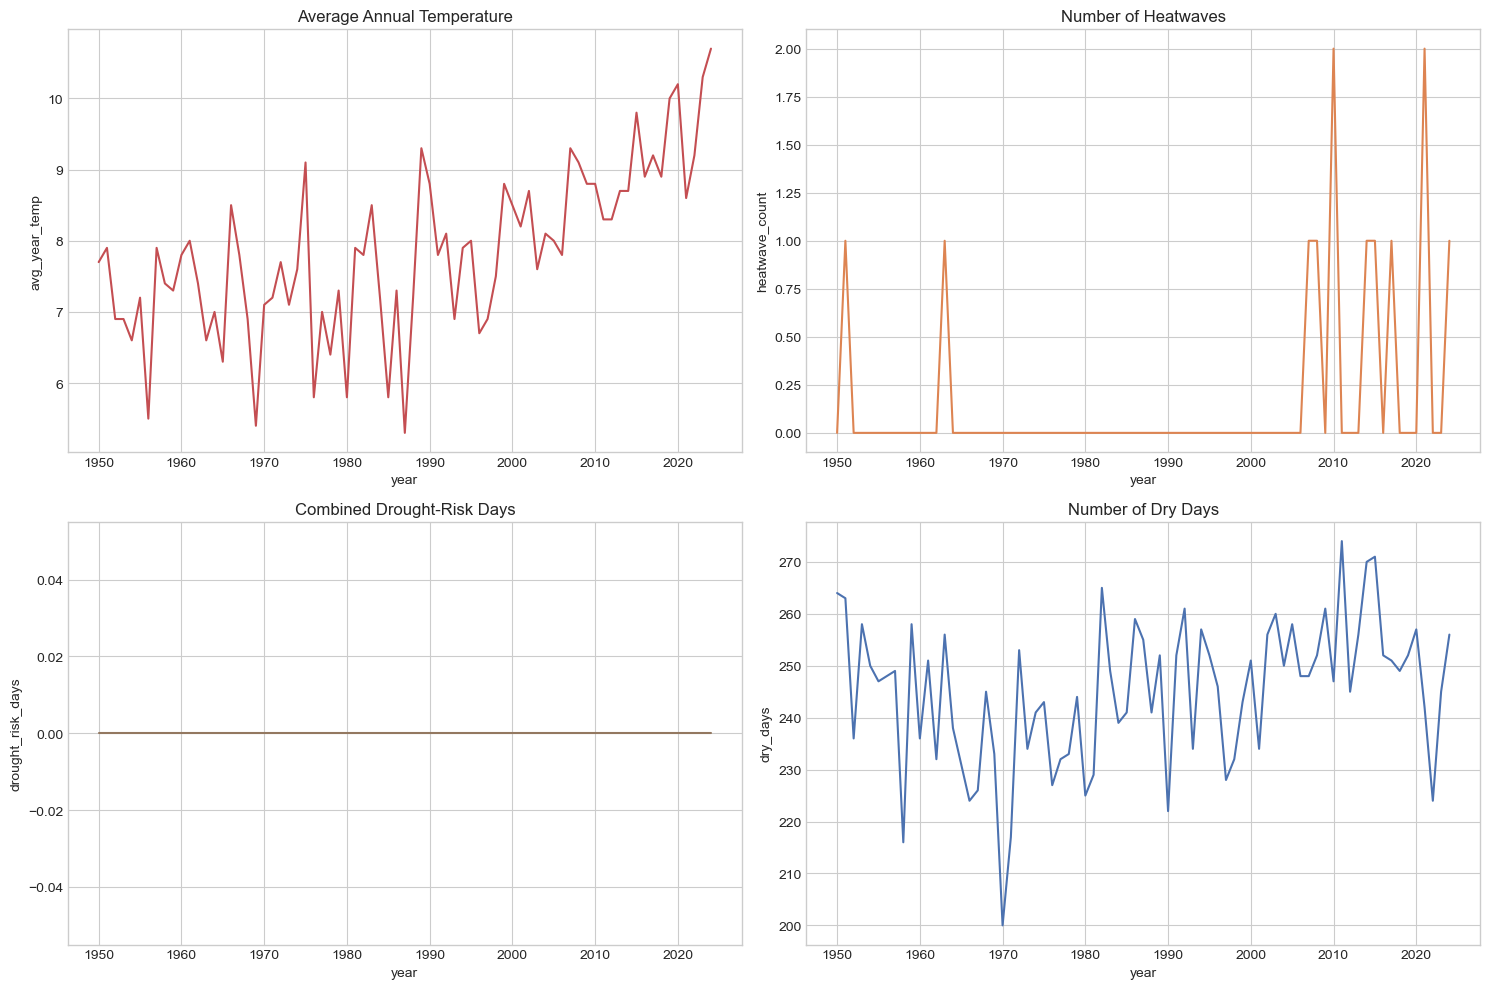

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.lineplot(data=features, x="year", y="avg_year_temp", ax=axes[0, 0], color="#c44e52")
axes[0, 0].set_title("Average Annual Temperature")

sns.lineplot(data=features, x="year", y="heatwave_count", ax=axes[0, 1], color="#dd8452")
axes[0, 1].set_title("Number of Heatwaves")

sns.lineplot(data=features, x="year", y="drought_risk_days", ax=axes[1, 0], color="#937860")
axes[1, 0].set_title("Combined Drought-Risk Days")

sns.lineplot(data=features, x="year", y="dry_days", ax=axes[1, 1], color="#4c72b0")
axes[1, 1].set_title("Number of Dry Days")

plt.tight_layout()
plt.show()

## Selecting the Number of Clusters

The clustering quality is evaluated using `silhouette_score`. For academic interpretation, the final analysis is presented with three scenarios.

In [8]:
feature_cols = [col for col in features.columns if col != "year"]

X = features[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scores = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append({"k": k, "silhouette_score": score})

scores_df = pd.DataFrame(scores)
display(scores_df)

best_k = int(scores_df.loc[scores_df["silhouette_score"].idxmax(), "k"])
print("Best k according to silhouette_score:", best_k)

,k,silhouette_score
0,2,0.361561
1,3,0.212231
2,4,0.239061
3,5,0.196707
4,6,0.201166


Best k according to silhouette_score: 2


## K-means Clustering of Yearly Profiles

In [9]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
features["cluster_id"] = kmeans.fit_predict(X_scaled)

risk_cols = [
    "avg_year_temp",
    "avg_apparent_temp",
    "heatwave_count",
    "drought_risk_days",
    "dry_days",
    "high_et0_days",
    "low_soil_moisture_days",
]

cluster_summary = features.groupby("cluster_id")[feature_cols].mean().round(2)
cluster_risk = features.groupby("cluster_id")[risk_cols].mean().mean(axis=1).sort_values()

scenario_map = {}
ordered_clusters = cluster_risk.index.tolist()
scenario_names = ["Stable", "Transitional", "Unfavorable"]
for cid, name in zip(ordered_clusters, scenario_names):
    scenario_map[cid] = name

features["scenario"] = features["cluster_id"].map(scenario_map)
cluster_summary["scenario"] = cluster_summary.index.map(scenario_map)

display(cluster_summary.sort_values("scenario"))
display(features[["year", "cluster_id", "scenario"]].head(15))

,avg_year_temp,median_year_temp,min_year_temp,max_year_temp,avg_apparent_temp,median_apparent_temp,min_apparent_temp,max_apparent_temp,avg_relative_humidity,dry_days,rainy_days,max_daily_precipitation_mm,heatwave_count,heatwave_avg_duration_days,heatwave_min_duration_days,heatwave_max_duration_days,drought_risk_days,high_et0_days,low_soil_moisture_days,max_wind_speed_km_h,strong_wind_days_50kmh,scenario
cluster_id,,,,,,,,,,,,,,,,,,,,,,
0,6.98,7.57,-20.58,29.99,4.01,4.15,-26.26,25.72,77.44,240.58,124.68,32.08,0.0,0.00,0.0,0.0,0.0,44.58,0.0,40.90,0.05,Stable
1,8.64,9.32,-15.69,31.74,5.89,6.21,-21.26,27.36,75.88,247.33,117.93,30.76,0.0,0.00,0.0,0.0,0.0,62.30,0.0,38.74,0.00,Transitional
2,8.87,8.72,-17.48,34.08,6.12,5.56,-23.44,28.92,73.68,255.60,109.60,25.73,1.2,6.45,6.0,6.9,0.0,78.50,0.0,37.06,0.00,Unfavorable


,year,cluster_id,scenario
0,1950,0,Stable
1,1951,2,Unfavorable
2,1952,0,Stable
3,1953,0,Stable
4,1954,0,Stable
5,1955,0,Stable
6,1956,0,Stable
7,1957,1,Transitional
8,1958,0,Stable
9,1959,0,Stable


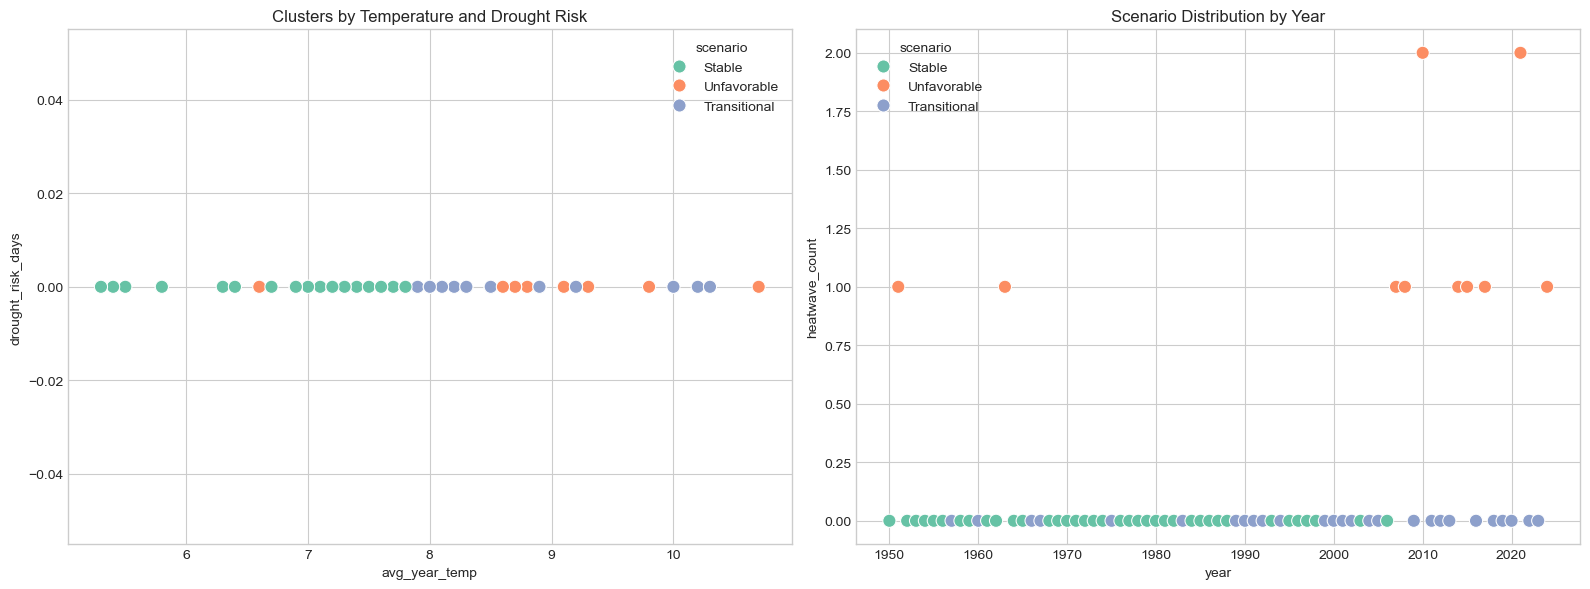

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=features,
    x="avg_year_temp",
    y="drought_risk_days",
    hue="scenario",
    palette="Set2",
    s=90,
    ax=axes[0]
)
axes[0].set_title("Clusters by Temperature and Drought Risk")

sns.scatterplot(
    data=features,
    x="year",
    y="heatwave_count",
    hue="scenario",
    palette="Set2",
    s=90,
    ax=axes[1]
)
axes[1].set_title("Scenario Distribution by Year")

plt.tight_layout()
plt.show()

## Analysis of Recent Years

In [11]:
recent_years = features[features["year"] >= 2020].copy()
display(recent_years[["year", "scenario", "avg_year_temp", "heatwave_count", "drought_risk_days", "dry_days"]])

scenario_counts = features["scenario"].value_counts().rename_axis("scenario").reset_index(name="years_count")
display(scenario_counts)

recent_summary = recent_years.groupby("scenario").size().rename("count").reset_index()
display(recent_summary)

,year,scenario,avg_year_temp,heatwave_count,drought_risk_days,dry_days
70,2020,Transitional,10.2,0.0,0,257
71,2021,Unfavorable,8.6,2.0,0,242
72,2022,Transitional,9.2,0.0,0,224
73,2023,Transitional,10.3,0.0,0,245
74,2024,Unfavorable,10.7,1.0,0,256


,scenario,years_count
0,Stable,38
1,Transitional,27
2,Unfavorable,10


,scenario,count
0,Transitional,3
1,Unfavorable,2


In [12]:
cluster_short = (
    features.groupby("scenario")[["avg_year_temp", "heatwave_count", "drought_risk_days", "dry_days", "rainy_days"]]
    .mean()
    .round(2)
    .sort_index()
)

display(cluster_short)

warmest_year = int(features.loc[features["avg_year_temp"].idxmax(), "year"])
most_drought_year = int(features.loc[features["drought_risk_days"].idxmax(), "year"])

print("Warmest year in the sample:", warmest_year)
print("Year with the highest number of drought-risk days:", most_drought_year)

,avg_year_temp,heatwave_count,drought_risk_days,dry_days,rainy_days
scenario,,,,,
Stable,6.98,0.0,0.0,240.58,124.68
Transitional,8.64,0.0,0.0,247.33,117.93
Unfavorable,8.87,1.2,0.0,255.60,109.60


Warmest year in the sample: 2024
Year with the highest number of drought-risk days: 1950


## Conclusions

1. Based on daily meteorological observations for 1950-2024, yearly climate profiles were constructed for Kyiv.
2. The feature set includes temperature indicators, heatwave characteristics, dry days, drought-risk measures, and wind extremes.
3. The `K-means` algorithm divided the years into three meaningful groups interpreted as stable, transitional, and unfavorable climate scenarios.
4. The unfavorable scenario is associated with higher temperatures, more frequent heatwaves, and stronger signs of dryness and drought stress.
5. Recent years were compared with the identified clusters, demonstrating how the model can support scenario-based climate risk assessment.

The analysis also shows that the warmest year in the sample is 2024, while the strongest drought-risk expression was observed in 1950.